<a href="https://colab.research.google.com/github/ojasvi-1705/Applied-Machine-Learning/blob/main/Exp8_PCA_KNN_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report


In [4]:
# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  target
0                5.1               3.5  ...               0.2       0
1                4.9               3.0  ...               0.2       0
2                4.7               3.2  ...               0.2       0
3                4.6               3.1  ...               0.2       0
4                5.0               3.6  ...               0.2       0

[5 rows x 5 columns]


In [7]:
# standarization
scaler = StandardScaler()
X_std= scaler.fit_transform(df.iloc[:,:-1])
print("\nStandardized Data (first 5 rows): ")
print(X_std[:5])


Standardized Data (first 5 rows): 
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]



Correlation Matrix:
                   sepal length (cm)  ...  petal width (cm)
sepal length (cm)           1.000000  ...          0.817941
sepal width (cm)           -0.117570  ...         -0.366126
petal length (cm)           0.871754  ...          0.962865
petal width (cm)            0.817941  ...          1.000000

[4 rows x 4 columns]


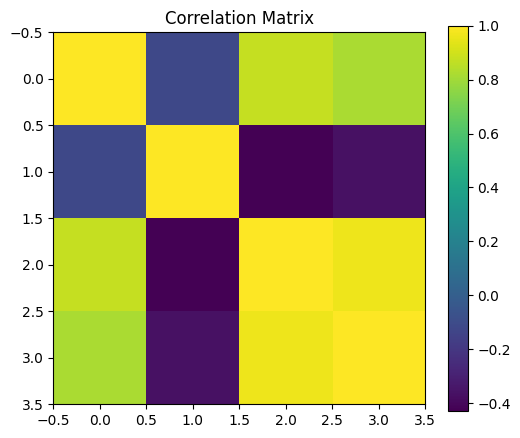

In [8]:
# 3. Correlation Matrix
corr_matris = pd.DataFrame(X_std).corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, interpolation ='nearest')
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()


In [9]:
# 4.Covarience Matrix

cov_matrix = np.cov(X_std.T)
print("\nCovarience Matrix:")
print(cov_matrix)


Covarience Matrix:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [10]:
# 5. Eigen Values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)
print("\nEigen Values:")
print(eigen_values)
print("\nEigen Vectors:")
print(eigen_vectors)



Eigen Values:
[2.93808505 0.9201649  0.14774182 0.02085386]

Eigen Vectors:
[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [11]:
  # 6. Sort Eigen Values (DEscending)
sorted_index = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_index]
eigen_vectors = eigen_vectors[:, sorted_index]
print("\nSorted Eigen Values:")
print(eigen_values)


Sorted Eigen Values:
[2.93808505 0.9201649  0.14774182 0.02085386]


In [12]:
# 7. select top 2 eigen vectors
W = eigen_vectors[:,:2]
print("\nTop 2 Eigen Vectors:")
print(W)


Top 2 Eigen Vectors:
[[ 0.52106591 -0.37741762]
 [-0.26934744 -0.92329566]
 [ 0.5804131  -0.02449161]
 [ 0.56485654 -0.06694199]]


In [13]:
# 8. PCA Transformation
X_pca = np.dot(X_std, W)
print("\n Shape after PCA :", X_pca.shape)


 Shape after PCA : (150, 2)


In [14]:
# SPlit Data
X_train , X_test , y_train, y_test = train_test_split(X_pca,y,test_size=0.2, random_state = 42)



In [25]:
#apply KNN
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[np.argmax(accuracies)]
print("Best K value:", best_k)

# ==============================
# 6. Train final model
# ==============================
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

Best K value: 2


KNeighborsClassifier(n_neighbors=2)

In [26]:
# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


In [27]:
# accuracy and report
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [31]:
print("K values with Accuracy:\n")

for k, acc in zip(k_values, accuracies):
    print(f"K = {k} -- Accuracy = {acc:.4f}")

# Best K
best_k = k_values[np.argmax(accuracies)]
print("\nBest K value:", best_k)

K values with Accuracy:

K = 1 -- Accuracy = 0.8667
K = 2 -- Accuracy = 0.9333
K = 3 -- Accuracy = 0.9333
K = 4 -- Accuracy = 0.9000
K = 5 -- Accuracy = 0.9333
K = 6 -- Accuracy = 0.9000
K = 7 -- Accuracy = 0.8667
K = 8 -- Accuracy = 0.9000
K = 9 -- Accuracy = 0.9000
K = 10 -- Accuracy = 0.9000
K = 11 -- Accuracy = 0.9000
K = 12 -- Accuracy = 0.9000
K = 13 -- Accuracy = 0.9000
K = 14 -- Accuracy = 0.9333
K = 15 -- Accuracy = 0.9000
K = 16 -- Accuracy = 0.9333
K = 17 -- Accuracy = 0.9333
K = 18 -- Accuracy = 0.9333
K = 19 -- Accuracy = 0.9333
K = 20 -- Accuracy = 0.9333

Best K value: 2


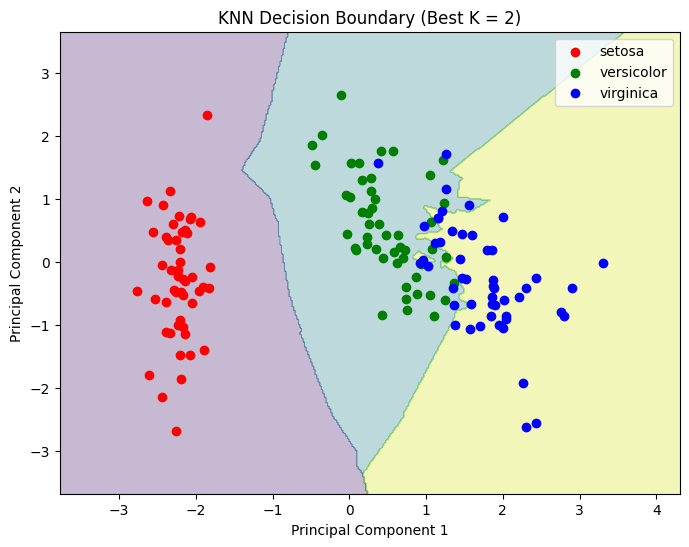

In [29]:
#7. Plot Decision Boundary

# Create mesh grid
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

# Predict for grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points
for i, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        c=color,
        label=iris.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"KNN Decision Boundary (Best K = {best_k})")
plt.legend()
plt.show()